In [29]:
!pip install sentence-transformers umap-learn scikit-learn tqdm



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
#imports 
import pandas as pd
import numpy as np
import re
from tqdm import tqdm
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

import umap.umap_ as umap


In [3]:
path = r"C:\Users\natra\OneDrive\Documents\NLP Project\dataset\indian_supreme_court_judgments.csv"  
df = pd.read_csv(path)

print("Columns:\n", df.columns)
df.head(2)


Columns:
 Index(['id', 'petitioner', 'respondent', 'date_of_judgment', 'bench', 'act',
       'headnote', 'citations', 'judgment_text', 'raw_text'],
      dtype='object')


,id,petitioner,respondent,date_of_judgment,bench,act,headnote,citations,judgment_text,raw_text
0,5-2021_MA-000083-2021,the Government of India,the,2020-01-09,NaN,NaN,background in which the above applications hav...,NaN,Non-Reportable IN THE SUPREME COURT OF INDIA C...,Non-Reportable IN THE SUPREME COURT OF INDIA C...
1,28-2021_C.A.No.-000867-000867-2021,the Directorate of Medical Education & People’...,Appeals & Niyam & the State of Madhya Pradesh,2021-03-02,NaN,NaN,NaN,Ors. v. Medical; Ors. v. State; Ors. v. State;...,Reportable IN THE SUPREME COURT OF INDIA CIVIL...,Reportable IN THE SUPREME COURT OF INDIA CIVIL...


In [5]:
#Clean Indian Legal Text
def clean_indian_legal_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    text = re.sub(r'IN THE .*? COURT OF INDIA', ' ', text, flags=re.I)
    text = re.sub(r'\b[A-Z]*\s?No\.?\s?\d+\/?\d*\b', ' ', text)
    text = re.sub(r'\(\d{4}\).*?\d+', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)

    return text.strip()


df["clean_text"] = df["raw_text"].astype(str).apply(clean_indian_legal_text)

df[["clean_text"]].head()


,clean_text
0,Non Reportable CIVIL APPELLATE JURISDICTION M ...
1,Reportable CIVIL APPELLATE JURISDICTION Civil ...
2,NON REPORTABLE CRIMINAL APPELLATE JURISDICTION...
3,Reportable CIVIL APPELLATE JURISDICTION Specia...
4,1 REPORTABLE CIVIL APPELLATE JURISDICTION CIVI...


In [7]:
#DAERM
def build_daerm_prompt(row):
    act = str(row.get("act", "unknown"))
    bench = str(row.get("bench", "unknown"))
    headnote = str(row.get("headnote", ""))
    judgment = str(row.get("judgment_text", ""))

    prefix = f"""
    [ACT]: {act}
    [BENCH]: {bench}
    [JUDGMENT_TYPE]: {judgment}
    [HEADNOTE]: {headnote}
    """

    return prefix + " " + row["clean_text"]


df["daerm_text"] = df.apply(build_daerm_prompt, axis=1)

df["daerm_text"].iloc[0][:400]


'\n    [ACT]: nan\n    [BENCH]: nan\n    [JUDGMENT_TYPE]: Non-Reportable IN THE SUPREME COURT OF INDIA CIVIL APPELLATE JURISDICTION M. A. No.83 of 2021 In M. A. (Diary) No.9887 of 2020 In Civil Appeal Nos. 6328-6399 of 2015 Union of India .... Applicant(s) Versus Association of Unified Telecom Service Providers of India and Ors. …. Respondent (s) With M.A. No.115 of 2021 In M. A. (Diary) No.2450 of 20'

In [9]:
#Load Transformer
model = SentenceTransformer('all-MiniLM-L6-v2')


C:\Users\natra\anaconda3\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [11]:
#Generate Embeddings
sample_size = min(len(df), 2000)
df = df.sample(sample_size, random_state=42)

texts = df["daerm_text"].tolist()

embeddings = model.encode(
    texts,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embedding shape:", embeddings.shape)


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Embedding shape: (500, 384)


In [13]:
#Cosine Similarity
similarity_matrix = cosine_similarity(embeddings)


In [15]:
#KMeans Clustering
num_clusters = 10

kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df["cluster"] = kmeans.fit_predict(embeddings)

df[["id", "cluster"]].head()


,id,cluster
361,13828-2019_C.A.No.-000814-000815-2021,9
73,2390-2020_C.A.No.-005685-005685-2021,3
374,14346-2018_Crl.A.No.-001216-001216-2019,7
155,5445-2014_W.P.(C)No.-000229-000229-2014,4
104,3598-2021_Crl.A.No.-001043-001043-2021,7


C:\Users\natra\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


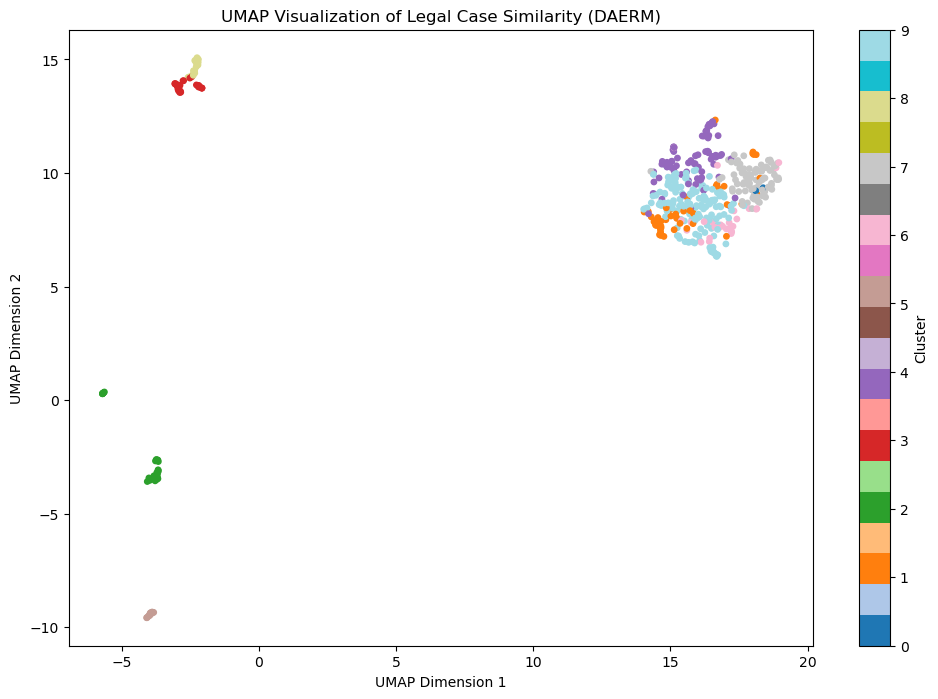

In [17]:
#Colored UMAP Visualization
reducer = umap.UMAP(random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

plt.figure(figsize=(12,8))
scatter = plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=df["cluster"],
    cmap="tab20",
    s=15
)

plt.title("UMAP Visualization of Legal Case Similarity (DAERM)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.colorbar(scatter, label="Cluster")
plt.show()


In [19]:
#Keyword Extraction
def extract_keywords(text, top_n=15):
    words = text.lower().split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) > 3]

    freq = {}
    for w in words:
        freq[w] = freq.get(w, 0) + 1

    keywords = sorted(freq, key=freq.get, reverse=True)[:top_n]
    return set(keywords)


In [21]:
#SHOW SIMILAR CASES
doc_id = 0   # change query case

scores = similarity_matrix[doc_id]
top_idx = np.argsort(scores)[::-1][1:6]

query = df.iloc[doc_id]
query_keywords = extract_keywords(query["clean_text"])

print("="*80)
print("QUERY CASE")
print("="*80)
print("ID:", query.get("id"))
print("ACT:", query.get("act"))
print("BENCH:", query.get("bench"))
print("\nTEXT PREVIEW:\n", query["clean_text"][:300])

print("\n\nSIMILAR CASES")
print("="*80)

for i in top_idx:
    r = df.iloc[i]
    sim_keywords = extract_keywords(r["clean_text"])
    common = query_keywords.intersection(sim_keywords)

    print("\n----------------------------------")
    print("ID:", r.get("id"))
    print("Similarity Score:", round(float(scores[i]), 4))
    print("ACT:", r.get("act"))
    print("BENCH:", r.get("bench"))
    print("Common Legal Terms:", list(common)[:5])

    if len(common) > 0:
        print("Reason: Shared legal concepts.")
    else:
        print("Reason: Semantic similarity from embeddings.")

    print("TEXT PREVIEW:\n", r["clean_text"][:200])


QUERY CASE
ID: 13828-2019_C.A.No.-000814-000815-2021
ACT: nan
BENCH: nan

TEXT PREVIEW:
 1 REPORTABLE CIVIL APPELLATE JURISDICTION CIVIL APPEAL NOS 814 815 Of 2021 arising out of SLP C Nos 11009 11010 of 2019 MADAN MOHAN SINGH APPELLANT S VERSUS VED PRAKASH ARYA RESPONDENT S J U D G M E N T ASHOK BHUSHAN J Leave granted 2 These appeals have been filed by the appellant challenging the ju


SIMILAR CASES

----------------------------------
ID: 17500-2018_C.A.No.-007750-007751-2021
Similarity Score: 0.8866
ACT: nan
BENCH: nan
Common Legal Terms: ['plaintiff', 'dated', 'appellant', 'court', 'respondent']
Reason: Shared legal concepts.
TEXT PREVIEW:
 REPORTABLE CIVIL APPELLATE JURISDICTION Civil Appeal Nos 7750 7751 of 2021 Arising out of Special Leave Petition C Nos 12558 12559 of 2018 ANITA RANI Appellant s Versus ASHOK KUMAR ORS Respondent s J 

----------------------------------
ID: 17983-2021_C.A.No.-005620-005620-2021
Similarity Score: 0.8731
ACT: nan
BENCH: nan
Common Legal Terms: ['

In [23]:
#function to handle unseen case
def find_similar_for_new_case(new_text, top_k=5):
    
    cleaned = clean_indian_legal_text(new_text)
    daerm_input = f"[NEW_CASE] {cleaned}"
    new_embedding = model.encode([daerm_input], convert_to_numpy=True)

    scores = cosine_similarity(new_embedding, embeddings)[0]
    top_idx = np.argsort(scores)[::-1][:top_k]

    query_keywords = extract_keywords(cleaned)

    print("="*80)
    print("NEW CASE SUMMARY")
    print("="*80)
    print(better_preview(cleaned, 400))

    print("\n\nMOST RELEVANT PRECEDENTS")
    print("="*80)

    for rank, i in enumerate(top_idx, start=1):
        r = df.iloc[i]
        sim_keywords = extract_keywords(r["clean_text"])
        common = query_keywords.intersection(sim_keywords)

        print(f"\n🔹 Rank {rank}")
        print("----------------------------------")
        print("Case ID:", r.get("id"))
        print("Similarity:", round(float(scores[i]), 3))

        # strong explanation
        if len(common) > 0:
            print("Why similar → common legal themes:", ", ".join(list(common)[:5]))
        else:
            print("Why similar → contextual meaning captured by transformer.")

        print("Preview:", better_preview(r["clean_text"]))

def better_preview(text, n=200):
    text = re.sub(r'reportable|civil appellate jurisdiction|criminal appellate jurisdiction', '', text, flags=re.I)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()[:n]



In [27]:
#similar cases searcher 
new_case_text = """
The present appeal arises from a motor vehicle accident claim.
The claimant suffered serious injuries due to rash and negligent driving.
Compensation awarded by the tribunal is challenged as inadequate.
The appellant seeks enhancement of compensation.
"""

find_similar_for_new_case(new_case_text)


NEW CASE SUMMARY
The present appeal arises from a motor vehicle accident claim The claimant suffered serious injuries due to rash and negligent driving Compensation awarded by the tribunal is challenged as inadequate The appellant seeks enhancement of compensation


MOST RELEVANT PRECEDENTS

🔹 Rank 1
----------------------------------
Case ID: 9247-2021_C.A.No.-005926-005926-2021
Similarity: 0.647
Why similar → common legal themes: appeal, awarded, claimant, compensation
Preview: CA 5926 2021 1 Civil Appeal of 2021 Arising out of SLP C of 2021 Satya Prakash Dwivedi Appellant Versus Munna alias Chandrabhan Yadav Respondent and Others J U D G M E N T B V Nagarathna J 1 Leave gra

🔹 Rank 2
----------------------------------
Case ID: 7071-2020_C.A.No.-004800-004800-2021
Similarity: 0.638
Why similar → common legal themes: claim, injuries, compensation, accident
Preview: CIVIL APPEAL NO 4800 OF 2021 arising out of SLP C of 2021 The Oriental Insurance Company Limited APPELLANT S VERSUS Kahlo

In [ ]:
The present appeal arises from a motor vehicle accident claim.
The claimant suffered serious injuries due to rash and negligent driving.
Compensation awarded by the tribunal is challenged as inadequate.
The appellant seeks enhancement of compensation with interest.




In [ ]:
The present appeal arises under Section 166 of the Motor Vehicles Act, 1988.
The claimant sustained permanent disability due to a road traffic accident.
The Motor Accident Claims Tribunal awarded compensation, which the appellant
contends is insufficient. The appeal seeks enhancement of compensation
along with interest under the provisions of the Motor Vehicles Act.